In [1]:
import numpy as np
import matplotlib.pyplot as plt
from transforms3d.euler import euler2mat
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output

In [2]:
class Joint:
    def __init__(self, name, direction, length, axis, dof, limits):
        self.name = name
        self.direction = np.reshape(direction, [3, 1])
        self.length = length
        axis = np.deg2rad(axis)
        self.C = euler2mat(*axis)
        self.Cinv = np.linalg.inv(self.C)
        self.limits = np.zeros([3, 2])
        for lm, nm in zip(limits, dof):
            if nm == 'rx':
                self.limits[0] = lm
            elif nm == 'ry':
                self.limits[1] = lm
            else:
                self.limits[2] = lm
        self.parent = None
        self.children = []
        self.coordinate = None
        self.matrix = None

    def set_motion(self, motion):
        if self.name == 'root':
            self.coordinate = np.reshape(np.array(motion['root'][:3]), [3, 1])
            rotation = np.deg2rad(motion['root'][3:])
            self.matrix = self.C.dot(euler2mat(*rotation)).dot(self.Cinv)
        else:
            idx = 0
            rotation = np.zeros(3)
            for axis, lm in enumerate(self.limits):
                if not np.array_equal(lm, np.zeros(2)):
                    rotation[axis] = motion[self.name][idx]
                    idx += 1
            rotation = np.deg2rad(rotation)
            self.matrix = self.parent.matrix.dot(self.C).dot(euler2mat(*rotation)).dot(self.Cinv)
            self.coordinate = self.parent.coordinate + self.length * self.matrix.dot(self.direction)
        for child in self.children:
            child.set_motion(motion)

    def draw(self):
        joints = self.to_dict()
        fig = plt.figure()
        ax = Axes3D(fig, auto_add_to_figure=False)
        fig.add_axes(ax)

        ax.set_xlim3d(-50, 10)
        ax.set_ylim3d(-20, 40)
        ax.set_zlim3d(-20, 40)

        xs, ys, zs = [], [], []
        for joint in joints.values():
            xs.append(joint.coordinate[0, 0])
            ys.append(joint.coordinate[1, 0])
            zs.append(joint.coordinate[2, 0])
        plt.plot(zs, xs, ys, 'b.')

        for joint in joints.values():
            child = joint
            if child.parent is not None:
                parent = child.parent
                xs = [child.coordinate[0, 0], parent.coordinate[0, 0]]
                ys = [child.coordinate[1, 0], parent.coordinate[1, 0]]
                zs = [child.coordinate[2, 0], parent.coordinate[2, 0]]
                plt.plot(zs, xs, ys, 'r')
        plt.show()

    def to_dict(self):
        ret = {self.name: self}
        for child in self.children:
            ret.update(child.to_dict())
        return ret

def parse_asf(file_path):
    '''read joint data only'''
    with open(file_path) as f:
        content = f.read().splitlines()

    for idx, line in enumerate(content):
        if line == ':bonedata':
            content = content[idx+1:]
            break

    joints = {'root': Joint('root', np.zeros(3), 0, np.zeros(3), [], [])}
    idx = 0
    while True:
        
        line = content[idx].strip().split()
        idx += 1
        if line[0] == ':hierarchy':
            break

        if line[0] == 'begin':
            joint = {}
            while True:
                line = content[idx].strip().split()
                idx += 1
                if line[0] == 'end':
                    break
                if line[0] == 'name':
                    joint['name'] = line[1]
                elif line[0] == 'direction':
                    joint['direction'] = [float(axis) for axis in line[1:]]
                elif line[0] == 'length':
                    joint['length'] = float(line[1])
                elif line[0] == 'axis':
                    joint['axis'] = [float(axis) for axis in line[1:-1]]
                elif line[0] == 'dof':
                    joint['dof'] = line[1:]
                elif line[0] == 'limits':
                    limits_str = ' '.join(line[1:])
                    limits = limits_str.replace('(', '').replace(')', '').split()
                    joint.setdefault('limits', []).append([float(x) for x in limits])

            joints[joint['name']] = Joint(
                joint['name'],
                joint['direction'],
                joint['length'],
                joint['axis'],
                joint.get('dof', []),
                joint.get('limits', [])
            )

    while True:
        if line[0] == 'begin':
            break
        line = content[idx].strip().split()
        idx += 1

    while True:
        line = content[idx].strip().split()
        idx += 1
        if line[0] == 'end':
            break
        for joint_name in line[1:]:
            joints[line[0]].children.append(joints[joint_name])
            joints[joint_name].parent = joints[line[0]]

    return joints

def parse_amc(file_path):
    with open(file_path) as f:
        content = f.read().splitlines()

    for idx, line in enumerate(content):
        if line == ':DEGREES':
            content = content[idx+1:]
            break

    frames = []
    idx = 0
    line = content[idx].strip().split()
    idx += 1
    assert line[0].isnumeric()
    
    current_frame = {}
    while idx < len(content):
        line = content[idx].strip().split()
        idx += 1
        if not line:  
            continue
        if line[0].isnumeric():  
            frames.append(current_frame)
            current_frame = {}
        else: 
            current_frame[line[0]] = [float(x) for x in line[1:]]
    frames.append(current_frame)

    return frames


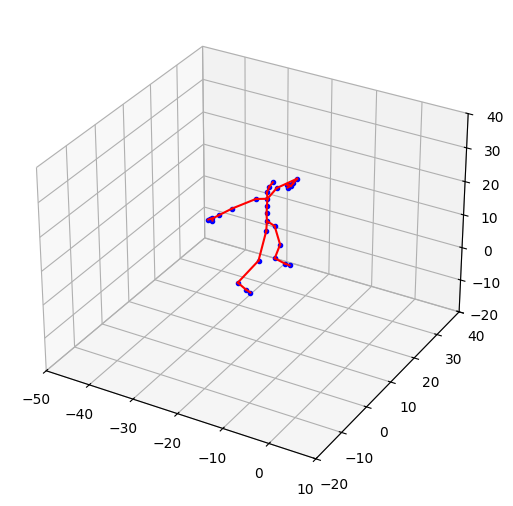

In [3]:
asf_path = "01.asf"
amc_path = "01_01.amc" 

joints = parse_asf(asf_path)
motions = parse_amc(amc_path)

joints['root'].set_motion(motions[0])
joints['root'].draw()

In [4]:
import time
from IPython.display import clear_output

def animate_motion(joints, motions, fps=30):
    for frame in range(len(motions)):
        
        clear_output(wait=True)
        joints['root'].set_motion(motions[frame])        
        joints['root'].draw()
        
        plt.title(f'Frame {frame + 1} / {len(motions)}')
        time.sleep(1/fps)

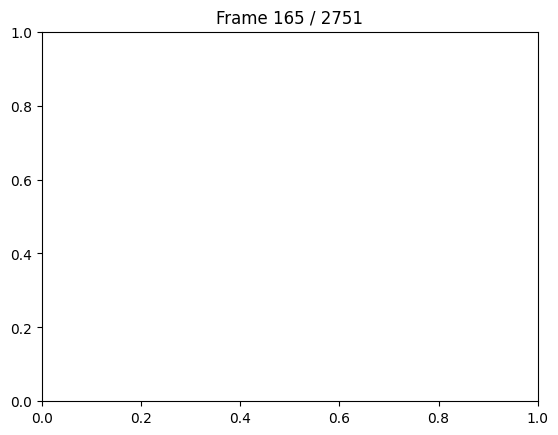

KeyboardInterrupt: 

: 

In [ ]:
animate_motion(joints, motions, fps=1000)

KeyboardInterrupt: 

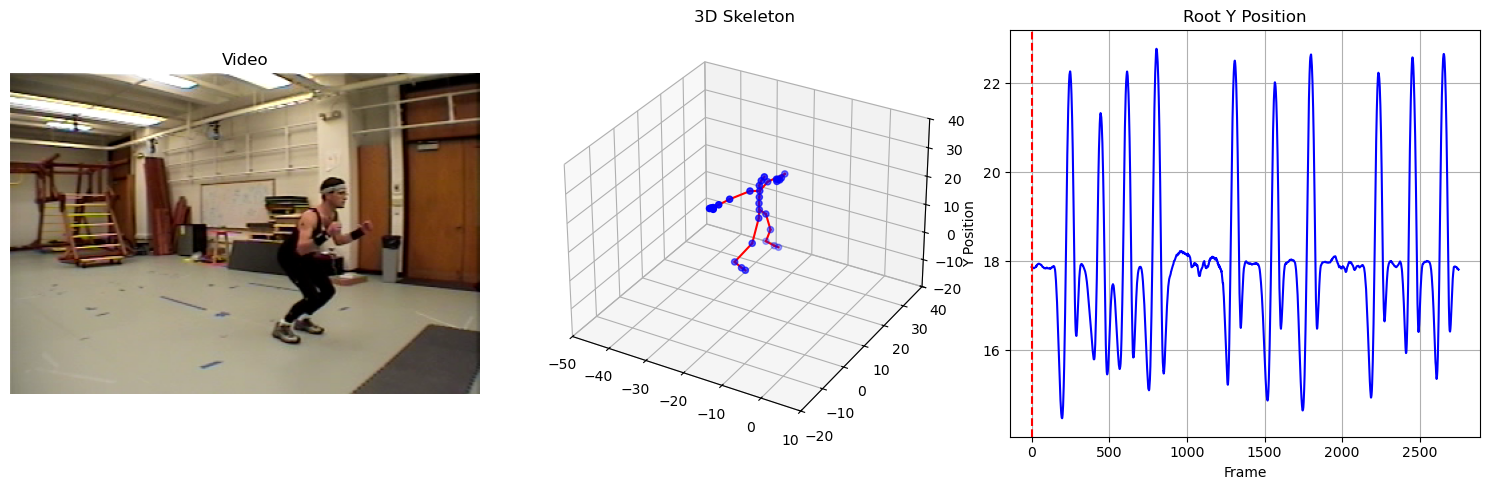

In [5]:
from motion_dashboard import create_dashboard
from IPython.display import HTML

anim = create_dashboard("01_01.mpg", "01.asf", "01_01.amc")
HTML(anim.to_jshtml())